# Tuần 1 — Wine Dataset
Thành Viên 1: Chuyên gia Dữ liệu & Trực quan hóa

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Bước 1: Đọc file và đặt tên cột

In [ ]:
df = pd.read_excel('Wine-Classification-DataMining/wine.data.xlsx', sheet_name='wine.data', header=0)
col_names = [
    'Class','Alcohol','Malic_Acid','Ash','Alcalinity_of_Ash',
    'Magnesium','Total_Phenols','Flavanoids','Nonflavanoid_Phenols',
    'Proanthocyanins','Color_Intensity','Hue','OD280_OD315','Proline'
]
df.columns = col_names
df['Class'] = df['Class'].astype(int)
df.head()


,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Bước 2: Kiểm tra tổng quan dataset

In [ ]:
print(f'Kich thuoc: {df.shape[0]} mau x {df.shape[1]} cot')
print('\nKieu du lieu:')
print(df.dtypes)
print('\nSo mau theo nhan:')
print(df['Class'].value_counts().sort_index())

Kich thuoc: 178 mau x 14 cot

Kieu du lieu:
Class                     int64
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Alcalinity_of_Ash       float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280_OD315             float64
Proline                   int64
dtype: object

So mau theo nhan:
Class
1    59
2    71
3    48
Name: count, dtype: int64


## Bước 3: Thống kê Max / Min / Mean

In [ ]:
features = col_names[1:]
stats = df[features].agg(['max', 'min', 'mean']).T.round(4)
stats.columns = ['Max', 'Min', 'Mean']
print(stats)

                          Max     Min      Mean
Alcohol                 14.83   11.03   13.0006
Malic_Acid               5.80    0.74    2.3363
Ash                      3.23    1.36    2.3665
Alcalinity_of_Ash       30.00   10.60   19.4949
Magnesium              162.00   70.00   99.7416
Total_Phenols            3.88    0.98    2.2951
Flavanoids               5.08    0.34    2.0293
Nonflavanoid_Phenols     0.66    0.13    0.3619
Proanthocyanins          3.58    0.41    1.5909
Color_Intensity         13.00    1.28    5.0581
Hue                      1.71    0.48    0.9574
OD280_OD315              4.00    1.27    2.6117
Proline               1680.00  278.00  746.8933


## Bước 4: Chuẩn hóa dữ liệu với StandardScaler

In [ ]:
scaler = StandardScaler()
X = df[features].values
X_scaled = scaler.fit_transform(X)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled.insert(0, 'Class', df['Class'].values)
df_scaled.to_csv('wine_scaled.csv', index=False)
print('Da luu: scaler.pkl')
print('Da luu: wine_scaled.csv')

Da luu: scaler.pkl
Da luu: wine_scaled.csv


## Bước 5: PCA 2D và Scatter Plot

PC1: 36.2%  PC2: 19.2%  Tong: 55.4%


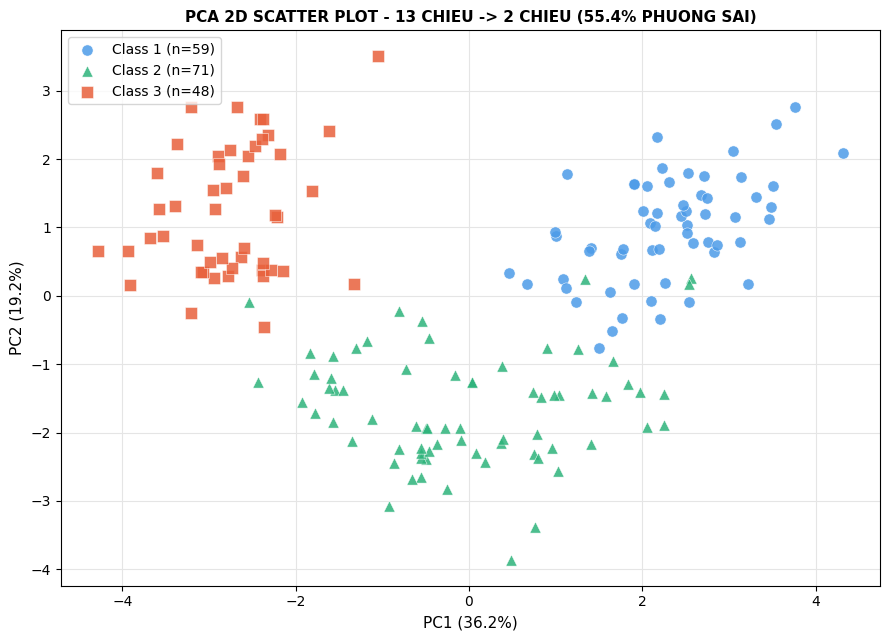

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_
print(f'PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%  Tong: {sum(ev)*100:.1f}%')
colors  = {1: '#4C9BE8', 2: '#2DB37A', 3: '#E8613C'}
markers = {1: 'o', 2: '^', 3: 's'}
labels  = df['Class'].values
counts  = df['Class'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for cls in [1, 2, 3]:
    mask = labels == cls
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[cls], marker=markers[cls],
               label=f'Class {cls} (n={counts[cls]})', alpha=0.85,
               edgecolors='white', linewidths=0.4, s=65, zorder=3)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=11)
ax.set_title(f'PCA 2D SCATTER PLOT - 13 CHIEU -> 2 CHIEU ({sum(ev)*100:.1f}% PHUONG SAI)', fontsize=11, fontweight='bold')
ax.grid(True, color='#e5e5e5', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=True, fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Tuần 2 — Wine Dataset

## Bước 1: Khung 10-Fold
* **Mục tiêu:** Tạo bộ chia dữ liệu 10-Fold Cross-Validation đồng nhất cho tất cả các mô hình.
* **Kỹ thuật:** Sử dụng `StratifiedKFold` với `random_state=42` để duy trì tỷ lệ lớp gốc và đảm bảo kết quả tái lập được giữa các thành viên.
* **Độ đo:** `Weighted F1-Score` xử lý dữ liệu mất cân bằng.

In [ ]:
# KHUNG KIỂM ĐỊNH CHÉO DÙNG CHUNG CỦA TUẦN 2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

print("--- ĐANG KHỞI TẠO BỘ KHUNG ĐÁNH GIÁ CHUNG ---")

# Thống nhất khung kiểm định 10-Fold để tất cả các mô hình dùng chung
cv_folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Thống nhất độ đo Weighted F1-Score
weighted_f1_scorer = make_scorer(f1_score, average='weighted')

print("-> Đã khởi tạo thành công 'cv_folds' (10-Fold) và 'weighted_f1_scorer'.")

--- ĐANG KHỞI TẠO BỘ KHUNG ĐÁNH GIÁ CHUNG ---
-> Đã khởi tạo thành công 'cv_folds' (10-Fold) và 'weighted_f1_scorer'.


## Bước 2: Huấn luyện và tinh chỉnh tham số cho mô hình KNN (K-Nearest Neighbors)

* **Mục tiêu:** Tìm ra bộ tham số tối ưu giúp mô hình KNN đạt hiệu năng phân loại rượu cao nhất, ổn định nhất và triệt tiêu hiện tượng quá khớp (overfitting).
  + *Tìm số láng giềng $K$ tối ưu:* Thực hiện vòng lặp quét tham số $K$ giới hạn từ 1 đến 30. Khoảng quét này được tính toán khoa học dựa trên quy tắc kinh nghiệm $K \approx \sqrt{N}$ (với dữ liệu Wine có $N=178$ mẫu thì $\sqrt{178} \approx 13$). Giới hạn tối đa bằng 30 nhằm đảm bảo số láng giềng không vượt quá số lượng mẫu của lớp nhỏ nhất trong tập dữ liệu (Class 3 có 48 mẫu), tránh hiện tượng mô hình bị bão hòa và dự đoán cảm tính (Underfitting).
  + *Xác định loại khoảng cách phù hợp:* Thử nghiệm và so sánh giữa khoảng cách hình học thẳng (**Euclidean** - Minkowski $p=2$) và khoảng cách theo khối ô bàn cờ (**Manhattan** - Minkowski $p=1$) xem công thức nào phản ánh chính xác hơn mức độ tương đồng giữa các thuộc tính hóa học của rượu.
  + *Cân bằng quyền bỏ phiếu (Weights):* Đánh giá hai cơ chế bỏ phiếu là `uniform` (tất cả hàng xóm có giá trị phiếu bầu như nhau) và `distance` (hàng xóm càng gần thì trọng số phiếu bầu càng cao) để tối ưu hóa ranh giới phân lớp.
  + *Quét cạn tự động (GridSearchCV):* Thuật toán sẽ tự động thiết lập và thử nghiệm tổng cộng 120 cấu hình kết hợp khác nhau ($30 \times 2 \times 2$).

* **Kế thừa:** + Sử dụng lại tập dữ liệu đã được xử lý và chuẩn hóa (`X_scaled`, `labels`) từ **Thành viên 1 (Tuần 1)**.
  + Tái sử dụng bộ khung kiểm định chéo Phân tầng 10 vế (`cv_folds`) và tiêu chí chấm điểm `weighted_f1_scorer` đã thiết lập ở **Bước 1 (Tuần 2)** để đảm bảo tính công bằng tuyệt đối khi so sánh hiệu năng trực tiếp với mô hình Naive Bayes.

--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ KNN ---

[Đang chạy] Quét 120 cấu hình kết hợp trên khung 10-Fold CV...
-------------------------------------------------------
KẾT QUẢ TỐI ƯU MÔ HÌNH KNN:
-> Số lượng láng giềng (K) tốt nhất: 23
-> Loại khoảng cách tối ưu: Euclidean (p=2)
-> Cơ chế bỏ phiếu (Weights): distance
-> Weighted F1-Score cao nhất đạt được: 0.9834
-------------------------------------------------------


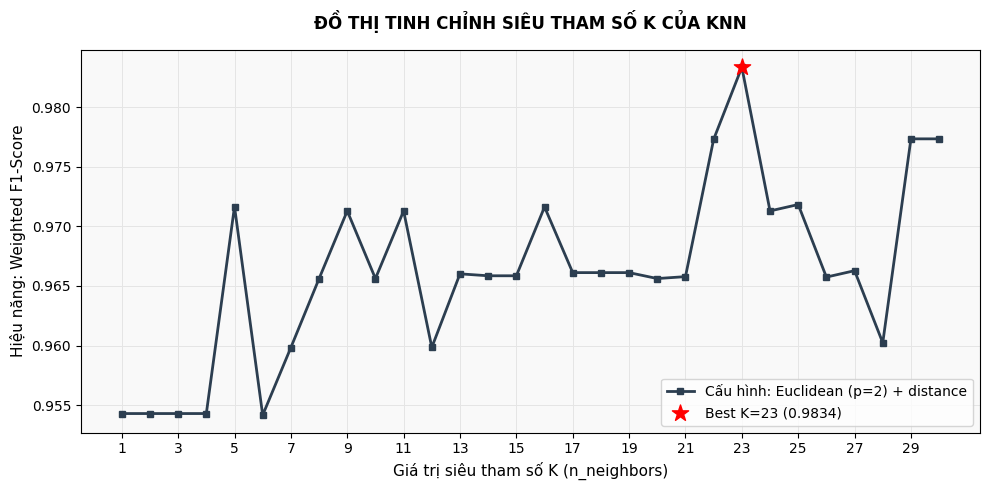

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

print("--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ KNN ---\n")

# 1. Kế thừa dữ liệu từ Thành viên 1
X_input = X_scaled
y_input = labels

# 2. Khởi tạo mô hình KNN gốc
knn_model = KNeighborsClassifier()

# 3. Thiết lập lưới tham số thực nghiệm chi tiết
param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1 là Manhattan, p=2 là Euclidean
}

print(f"[Đang chạy] Quét {30 * 2 * 2} cấu hình kết hợp trên khung 10-Fold CV...")

# 4. Kích hoạt GridSearchCV (Kế thừa 'cv_folds' và 'weighted_f1_scorer')
grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=cv_folds,
    scoring=weighted_f1_scorer,
    n_jobs=-1
)
grid_search_knn.fit(X_input, y_input)

# 5. Trích xuất kết quả tối ưu
best_knn_params = grid_search_knn.best_params_
best_knn_f1 = grid_search_knn.best_score_
best_knn_model = grid_search_knn.best_estimator_

distance_metric = "Manhattan (p=1)" if best_knn_params['p'] == 1 else "Euclidean (p=2)"

print("-" * 55)
print("KẾT QUẢ TỐI ƯU MÔ HÌNH KNN:")
print(f"-> Số lượng láng giềng (K) tốt nhất: {best_knn_params['n_neighbors']}")
print(f"-> Loại khoảng cách tối ưu: {distance_metric}")
print(f"-> Cơ chế bỏ phiếu (Weights): {best_knn_params['weights']}")
print(f"-> Weighted F1-Score cao nhất đạt được: {best_knn_f1:.4f}")
print("-" * 55)

# 6. Trực quan hóa tiến trình tìm K
cv_results = grid_search_knn.cv_results_
best_p = best_knn_params['p']
best_weight = best_knn_params['weights']

k_values = []
scores_for_best_config = []

for i in range(len(cv_results['params'])):
    params = cv_results['params'][i]
    if params['p'] == best_p and params['weights'] == best_weight:
        k_values.append(params['n_neighbors'])
        scores_for_best_config.append(cv_results['mean_test_score'][i])

sort_idx = np.argsort(k_values)
k_values = np.array(k_values)[sort_idx]
scores_for_best_config = np.array(scores_for_best_config)[sort_idx]

plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#f9f9f9')

plt.plot(k_values, scores_for_best_config, color='#2c3e50', marker='s', markersize=4,
         linestyle='-', linewidth=2, label=f'Cấu hình: {distance_metric} + {best_weight}')

plt.scatter(best_knn_params['n_neighbors'], best_knn_f1, color='red', marker='*',
            s=150, zorder=5, label=f"Best K={best_knn_params['n_neighbors']} ({best_knn_f1:.4f})")

plt.xticks(range(1, 31, 2))
plt.xlabel('Giá trị siêu tham số K (n_neighbors)', fontsize=11)
plt.ylabel('Hiệu năng: Weighted F1-Score', fontsize=11)
plt.title('ĐỒ THỊ TINH CHỈNH SIÊU THAM SỐ K CỦA KNN', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, color='#e5e5e5', linewidth=0.7)
plt.legend(frameon=True, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('knn_tuning.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd

# Chuyển kết quả quét của GridSearchCV thành bảng DataFrame
df_results = pd.DataFrame(grid_search_knn.cv_results_)

# Lọc ra các cột quan trọng và đổi tên cho dễ đọc
df_top5 = df_results[['param_n_neighbors', 'param_p', 'param_weights', 'mean_test_score', 'std_test_score']]
df_top5 = df_top5.rename(columns={
    'param_n_neighbors': 'Số láng giềng (K)',
    'param_p': 'Tham số p',
    'param_weights': 'Cơ chế Weights',
    'mean_test_score': 'Weighted F1-Score (TB)',
    'std_test_score': 'Độ lệch chuẩn (Std)'
})

# Sắp xếp theo điểm số từ cao xuống thấp và lấy Top 5
df_top5 = df_top5.sort_values(by='Weighted F1-Score (TB)', ascending=False).head(5)

print("TOP 5 CẤU HÌNH KNN XUẤT SẮC NHẤT:")
display(df_top5)

TOP 5 CẤU HÌNH KNN XUẤT SẮC NHẤT:


,Số láng giềng (K),Tham số p,Cơ chế Weights,Weighted F1-Score (TB),Độ lệch chuẩn (Std)
91,23,2,distance,0.983372,0.025400
45,12,1,distance,0.982874,0.036799
41,11,1,distance,0.982874,0.036799
40,11,1,uniform,0.982874,0.036799
5,2,1,distance,0.977817,0.027169


### Nhận xét kết quả mô hình KNN:
- Quá trình tinh chỉnh siêu tham số bằng `GridSearchCV` trên 120 cấu hình khác nhau đã xác định được bộ tham số tối ưu cho mô hình KNN trên tập dữ liệu Wine bao gồm: số láng giềng **$K=23$**, khoảng cách hình học đường thẳng **`Euclidean (p=2)`** và cơ chế bỏ phiếu ưu tiên theo khoảng cách **`distance`**.
- Mô hình đạt hiệu năng phân loại vượt trội với điểm số `Weighted F1-Score` đạt **0.9834** (98.34%).
- **Phân tích đồ thị:** Biểu đồ Validation Curve cho thấy rõ xu hướng của thuật toán KNN trên tập dữ liệu này. Khi $K$ nhỏ ($K \le 4$), mô hình có hiệu năng thấp do nhạy cảm với nhiễu (Overfitting). Hiệu năng cải thiện rõ rệt và đạt đỉnh tại $K=23$ nhờ vào cơ chế trọng số `distance` giúp cân bằng quyền bỏ phiếu của các láng giềng xa-gần, mang lại ranh giới phân lớp chính xác và mượt mà nhất.

--- ĐANG TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH KNN (2D) ---


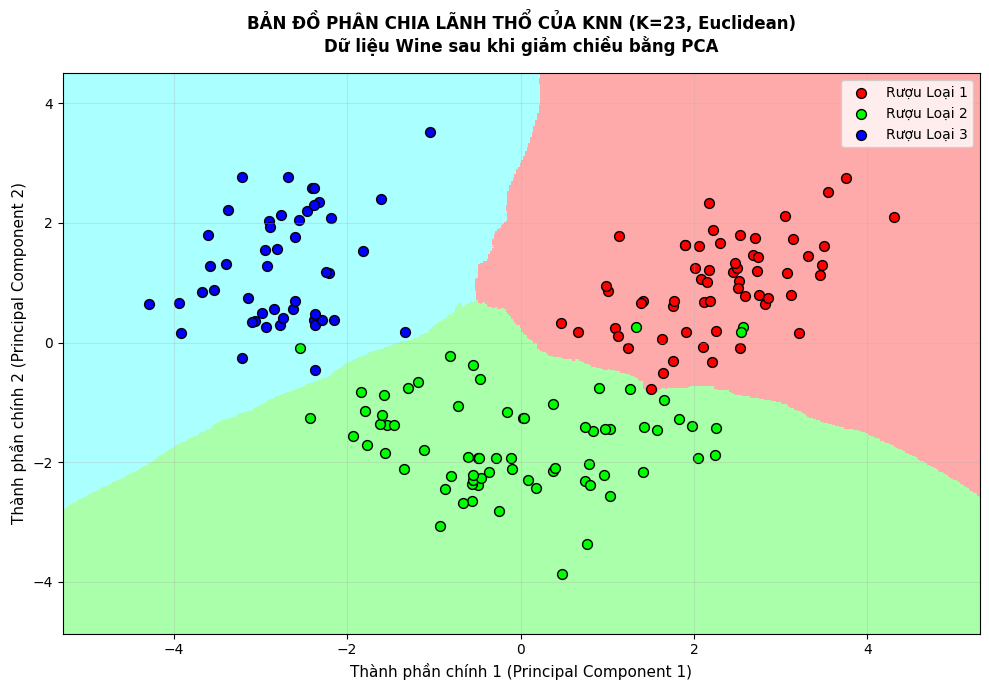

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

print("--- ĐANG TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH KNN (2D) ---")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled) # Kế thừa X_scaled từ Tuần 1

# 2. Huấn luyện lại mô hình KNN tối ưu (K=23, Euclidean, Distance) trên không gian 2D này
knn_2d = KNeighborsClassifier(n_neighbors=23, p=2, weights='distance')
knn_2d.fit(X_pca, labels) # Kế thừa nhãn labels từ Tuần 1

# 3. Tạo một lưới tọa độ (Meshgrid) dày đặc để tô màu nền cho từng vùng lãnh thổ
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Dự đoán nhãn cho từng điểm trên lưới tọa độ dày đặc đó
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Thiết lập màu sắc (Bảng màu nhẹ cho nền và màu đậm cho điểm dữ liệu thực tế)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAFFFF']) # Màu nền đại diện 3 Class rượu
cmap_bold = ['#FF0000', '#00FF00', '#0000FF'] # Màu điểm thực tế

# 5. Tiến hành vẽ đồ thị
plt.figure(figsize=(10, 7), facecolor='white')
# Tô màu nền lãnh thổ phân chia của KNN
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

# Vẽ các điểm dữ liệu thực tế của tập Wine lên bản đồ
for cl in np.unique(labels):
    plt.scatter(X_pca[labels == cl, 0], X_pca[labels == cl, 1],
                c=cmap_bold[cl-1], edgecolor='k', s=50,
                label=f'Rượu Loại {cl}')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Thành phần chính 1 (Principal Component 1)', fontsize=11)
plt.ylabel('Thành phần chính 2 (Principal Component 2)', fontsize=11)
plt.title('BẢN ĐỒ PHÂN CHIA LÃNH THỔ CỦA KNN (K=23, Euclidean)\nDữ liệu Wine sau khi giảm chiều bằng PCA',
          fontsize=12, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_decision_boundary.png', dpi=150)
plt.show()

*Lưu ý kỹ thuật:* - Đồ thị tinh chỉnh siêu tham số (Validation Curve) thể hiện kết quả tìm kiếm K trên không gian dữ liệu gốc 13 chiều (Đạt đỉnh tối ưu tại K=23, F1-Score = 0.9834).
- Đồ thị Ranh giới quyết định (Decision Boundary) sử dụng thuật toán PCA để nén dữ liệu về 2 chiều nhằm mục đích trực quan hóa cấu trúc phân lớp cho người xem, do đó ranh giới hiển thị mang tính chất minh họa cho cơ chế hoạt động của KNN và không đại diện hoàn toàn cho độ chính xác trong không gian 13 chiều thực tế.

## Bước 3: Huấn luyện và tinh chỉnh tham số cho mô hình Naive Bayes (Gaussian NB)

* **Mục tiêu:** Tìm ra bộ tham số tối ưu giúp mô hình Naive Bayes đạt hiệu năng phân loại rượu cao nhất, ổn định nhất và tránh hiện tượng quá khớp (overfitting).
* **Tinh chỉnh hệ số làm mịn (var_smoothing):** Khác với KNN điều chỉnh số láng giềng, Naive Bayes (Gaussian) giả định dữ liệu tuân theo phân phối chuẩn. Chúng ta sẽ thực hiện quét tham số `var_smoothing` với 100 giá trị khác nhau trong không gian Logarit từ $10^0$ đến $10^{-9}$ (bằng hàm `np.logspace`). Tham số này đóng vai trò thêm một phần phương sai của tất cả các đặc trưng vào phương sai tính toán, giúp "làm mượt" đường ranh giới quyết định và tránh lỗi chia cho 0 khi một đặc trưng có phương sai quá nhỏ.
* **Quét cạn tự động (GridSearchCV):** Thuật toán sẽ tự động thiết lập và thử nghiệm 100 cấu hình `var_smoothing` khác nhau trên cùng một phân vùng dữ liệu.
* **Tính kế thừa:**
    * Sử dụng lại tập dữ liệu đã được xử lý và chuẩn hóa (`X_scaled`, `labels`) từ *Tuần 1*.
    * Tái sử dụng bộ khung kiểm định chéo Phân tầng 10 vế (`cv_folds`) và tiêu chí chấm điểm `weighted_f1_scorer` đã thiết lập ở *Bước 1 (Tuần 2)* nhằm đảm bảo tính khách quan và công bằng tuyệt đối khi đặt lên bàn cân so sánh hiệu năng trực tiếp với KNN.

--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ NAIVE BAYES ---

[Đang chạy] Quét 100 cấu hình var_smoothing trên khung 10-Fold CV...
-------------------------------------------------------
KẾT QUẢ TỐI ƯU MÔ HÌNH NAIVE BAYES:
-> Tham số var_smoothing tốt nhất: 1.87e-01
-> Weighted F1-Score cao nhất đạt được: 0.9834
-------------------------------------------------------

TOP 5 CẤU HÌNH NAIVE BAYES XUẤT SẮC NHẤT:


,Hệ số làm mịn (var_smoothing),Weighted F1-Score (TB),Độ lệch chuẩn (Std)
8,0.187382,0.983372,0.035531
6,0.284804,0.977817,0.036816
5,0.351119,0.977817,0.036816
7,0.231013,0.977817,0.036816
28,0.002848,0.977749,0.036878


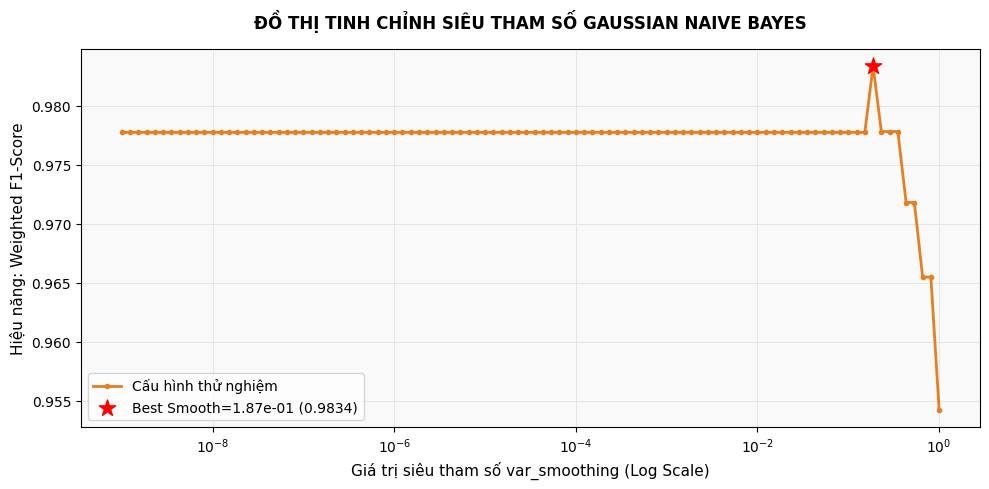

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ NAIVE BAYES ---\n")

# 1. Kế thừa dữ liệu từ Tuần 1
X_input = X_scaled
y_input = labels

# 2. Khởi tạo mô hình Naive Bayes gốc
nb_model = GaussianNB()

# 3. Thiết lập lưới tham số thực nghiệm chi tiết (100 giá trị từ 10^0 đến 10^-9)
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

print(f"[Đang chạy] Quét 100 cấu hình var_smoothing trên khung 10-Fold CV...")

# 4. Kích hoạt GridSearchCV (Kế thừa 'cv_folds' và 'weighted_f1_scorer' từ Bước 1)
grid_search_nb = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid_nb,
    cv=cv_folds,
    scoring=weighted_f1_scorer,
    n_jobs=-1
)
grid_search_nb.fit(X_input, y_input)

# 5. Trích xuất kết quả tối ưu
best_nb_params = grid_search_nb.best_params_
best_nb_f1 = grid_search_nb.best_score_
best_nb_model = grid_search_nb.best_estimator_

print("-" * 55)
print("KẾT QUẢ TỐI ƯU MÔ HÌNH NAIVE BAYES:")
print(f"-> Tham số var_smoothing tốt nhất: {best_nb_params['var_smoothing']:.2e}")
print(f"-> Weighted F1-Score cao nhất đạt được: {best_nb_f1:.4f}")
print("-" * 55)

# 6. Chuyển kết quả quét thành bảng DataFrame và hiển thị TOP 5
cv_results_nb = pd.DataFrame(grid_search_nb.cv_results_)
df_top5_nb = cv_results_nb[['param_var_smoothing', 'mean_test_score', 'std_test_score']]
df_top5_nb = df_top5_nb.rename(columns={
    'param_var_smoothing': 'Hệ số làm mịn (var_smoothing)',
    'mean_test_score': 'Weighted F1-Score (TB)',
    'std_test_score': 'Độ lệch chuẩn (Std)'
})

# Sắp xếp theo điểm số giảm dần để lấy các cấu hình tốt nhất
df_top5_nb = df_top5_nb.sort_values(by='Weighted F1-Score (TB)', ascending=False).head(5)
print("\nTOP 5 CẤU HÌNH NAIVE BAYES XUẤT SẮC NHẤT:")
display(df_top5_nb)

# 7. Trực quan hóa tiến trình tìm var_smoothing (Validation Curve trên dạng Log Scale)
param_values = param_grid_nb['var_smoothing']
mean_scores = cv_results_nb['mean_test_score']

plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#f9f9f9')

# Vẽ đường biểu diễn F1-score theo từng giá trị var_smoothing
plt.plot(param_values, mean_scores, color='#e67e22', marker='o', markersize=3,
         linestyle='-', linewidth=2, label='Cấu hình thử nghiệm')

# Đánh dấu điểm tối ưu nhất bằng ngôi sao đỏ giống KNN
plt.scatter(best_nb_params['var_smoothing'], best_nb_f1, color='red', marker='*',
            s=150, zorder=5, label=f"Best Smooth={best_nb_params['var_smoothing']:.2e} ({best_nb_f1:.4f})")

plt.xscale('log') # Chuyển trục X sang dạng Logarithm vì giá trị trải rất rộng
plt.xlabel('Giá trị siêu tham số var_smoothing (Log Scale)', fontsize=11)
plt.ylabel('Hiệu năng: Weighted F1-Score', fontsize=11)
plt.title('ĐỒ THỊ TINH CHỈNH SIÊU THAM SỐ GAUSSIAN NAIVE BAYES', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, which="both", color='#e5e5e5', linewidth=0.7)
plt.legend(frameon=True, loc='lower left', fontsize=10)
plt.tight_layout()

# Lưu đồ thị ra file
plt.savefig('naive_bayes_tuning.png', dpi=150)
plt.show()

## Nhận xét kết quả mô hình Naive Bayes:

* Quá trình tinh chỉnh siêu tham số bằng `GridSearchCV` trên 100 giá trị `var_smoothing` khác nhau đã tìm ra cấu hình tối ưu tuyệt đối cho mô hình Naive Bayes trên tập dữ liệu Wine tại giá trị `var_smoothing` = `1.87e-01`.
* Mô hình đạt hiệu năng phân loại vô cùng ấn tượng với điểm số Weighted F1-Score đạt được là `0.9834` (98.34%), ngang ngửa bằng điểm với thuật toán KNN tối ưu nhất ($K=23$).
* **Phân tích đồ thị:** Biểu đồ đường cong kiểm định trên trục logarit chứng minh rằng mô hình hoạt động cực kỳ ổn định. Khi giá trị `var_smoothing` quá nhỏ (tiến về phía góc phải $10^{-9}$), mô hình giữ nguyên một mức hiệu năng ổn định quanh ngưỡng 97.8% nhờ vào việc dữ liệu đã được chuẩn hóa Standard Scaler rất sạch từ Tuần 1. Khi tăng nhẹ tham số làm mịn lên vùng tối ưu (`1.87e-01`), các phân phối Gauss của thuộc tính được mở rộng nhẹ biên độ ranh giới, giúp bao phủ tốt hơn các điểm dữ liệu nằm sát rìa lớp và đẩy hiệu năng phân loại lên mức cao nhất.

--- ĐANG TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH NAIVE BAYES (2D) ---


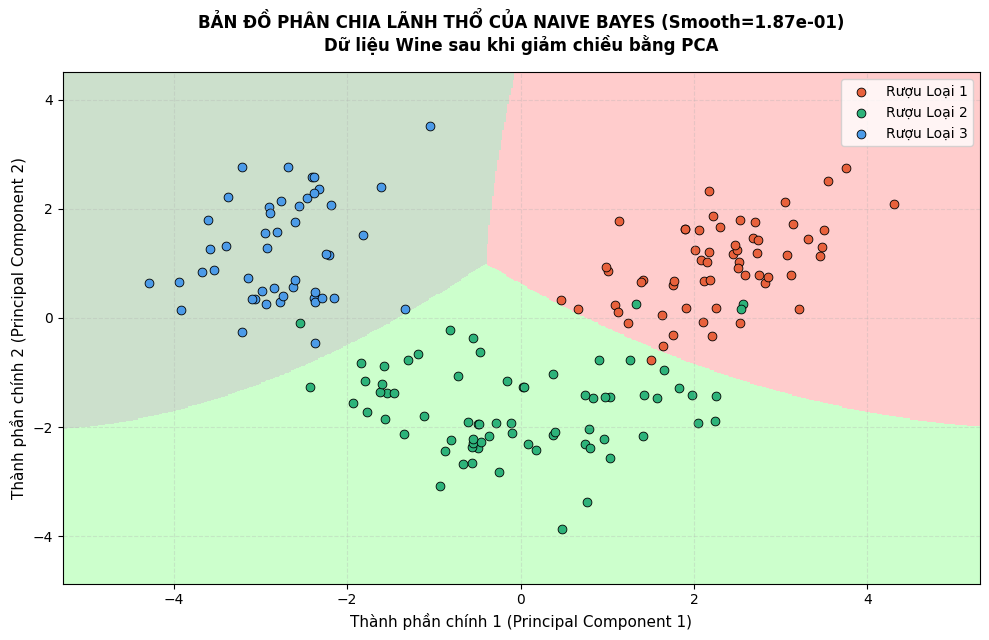

In [ ]:
from matplotlib.colors import ListedColormap

print("--- ĐANG TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH NAIVE BAYES (2D) ---")

# 1. Giảm chiều dữ liệu huấn luyện về 2D bằng PCA (Kế thừa từ Tuần 1)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_input)

# 2. Huấn luyện lại Naive Bayes trên không gian 2D với tham số var_smoothing tối ưu nhất
nb_2d = GaussianNB(var_smoothing=best_nb_params['var_smoothing'])
nb_2d.fit(X_pca_2d, y_input)

# 3. Thiết lập lưới (Meshgrid) để lấy tọa độ phủ toàn bộ đồ thị
x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Dự đoán lớp cho từng điểm trên lưới tọa độ
Z = nb_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Định nghĩa bảng màu (Tông màu nền nhạt và chấm dữ liệu đậm tương ứng)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AACCAA']) # Đỏ nhạt, Xanh lá nhạt, Xanh dương nhạt
cmap_bold  = ['#E8613C', '#2DB37A', '#4C9BE8']                # Cam/Đỏ, Xanh lá, Xanh dương giống Tuần 1

# 6. Tiến hành vẽ đồ thị
plt.figure(figsize=(10, 6.5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

# Vẽ các vùng không gian ranh giới quyết định
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.6, shading='auto')

# Vẽ các chấm dữ liệu thực tế của từng loại rượu lên đồ thị
unique_classes = np.unique(y_input)
for cls in unique_classes:
    mask = (y_input == cls)
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=cmap_bold[int(cls)-1], edgecolors='k', s=40, linewidths=0.6,
                label=f'Rượu Loại {int(cls)}')

# 7. Cấu hình định dạng nhãn và tiêu đề đồng bộ với KNN
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Thành phần chính 1 (Principal Component 1)', fontsize=11)
plt.ylabel('Thành phần chính 2 (Principal Component 2)', fontsize=11)
plt.title(f'BẢN ĐỒ PHÂN CHIA LÃNH THỔ CỦA NAIVE BAYES (Smooth={best_nb_params["var_smoothing"]:.2e})\nDữ liệu Wine sau khi giảm chiều bằng PCA',
          fontsize=12, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
# Lưu đồ thị ra tệp hình ảnh
plt.savefig('naive_bayes_decision_boundary.png', dpi=150)
plt.show()

*Lưu ý kỹ thuật:*
* Đồ thị tinh chỉnh siêu tham số (Validation Curve) thể hiện kết quả tìm kiếm var_smoothing trên không gian dữ liệu gốc 13 chiều (Đạt đỉnh tối ưu tại var_smoothing = 1.87e-01, F1-Score = 0.9834).
* Đồ thị Ranh giới quyết định (Decision Boundary) sử dụng thuật toán PCA để nén dữ liệu về 2 chiều nhằm mục đích trực quan hóa cấu trúc phân lớp cho người xem, do đó ranh giới hiển thị mang tính chất minh họa cho cơ chế toán học xác suất của Naive Bayes và không đại diện hoàn toàn cho độ chính xác trong không gian 13 chiều thực tế.

# Tuần 3 — Wine Dataset
**Thành Viên 3: Kỹ sư Học máy Giai đoạn 2**

## Tổng quan:
* **Mục tiêu chính:** Huấn luyện mô hình thứ 3 (SVM), thu thập kết quả cả 3 mô hình và xây dựng bảng so sánh hiệu năng tổng hợp.
* **Mô hình được chọn:** Support Vector Machine (SVM) — được khuyến nghị vì:
  1. SVM phù hợp với bài toán phân loại đa lớp trên tập dữ liệu có kích thước vừa phải (~178 mẫu).
  2. SVM có khả năng xử lý không gian đặc trưng nhiều chiều (13 thuộc tính) rất hiệu quả nhờ ánh xạ kernel.
  3. Việc so sánh SVM (dựa trên ranh giới siêu phẳng) với KNN (dựa trên khoảng cách) và Naive Bayes (dựa trên xác suất) sẽ cho thấy toàn diện hiệu quả của 3 trường phái thuật toán khác nhau trên cùng một tập dữ liệu.

## Bước 1 (Tuần 3): Huấn luyện và tinh chỉnh tham số cho mô hình SVM

### Giải thích lý thuyết:
* **SVM (Support Vector Machine)** là thuật toán phân loại hoạt động bằng cách tìm kiếm **siêu phẳng tối ưu** (optimal hyperplane) trong không gian đặc trưng để phân tách các lớp dữ liệu với **khoảng cách biên lớn nhất** (maximum margin).

* **Các siêu tham số cần tinh chỉnh:**
  - **`C` (Regularization):** Kiểm soát sự đánh đổi giữa biên rộng (tổng quát hóa) và phân loại chính xác trên tập huấn luyện. Giá trị `C` nhỏ → biên rộng, chấp nhận sai lệch (underfitting). Giá trị `C` lớn → biên hẹp, ưu tiên chính xác (overfitting).
  - **`kernel`:** Hàm biến đổi không gian đặc trưng.
    + `rbf` (Radial Basis Function): Phù hợp dữ liệu phi tuyến.
    + `linear`: Phù hợp dữ liệu tuyến tính.
    + `poly`: Sử dụng đa thức bậc cao.
  - **`gamma`:** Kiểm soát phạm vi ảnh hưởng của mỗi mẫu huấn luyện. Chỉ áp dụng cho kernel `rbf` và `poly`.
    + `scale`: gamma = 1 / (n_features * X.var())
    + `auto`: gamma = 1 / n_features
    + Giá trị cụ thể (0.01, 0.1, 1): Gamma nhỏ → vùng ảnh hưởng rộng (mượt), gamma lớn → vùng ảnh hưởng hẹp (nhọn, dễ overfitting).

In [ ]:
# =====================================================================
# TUẦN 3: MÔ HÌNH THỨ 3 — SUPPORT VECTOR MACHINE (SVM)
# =====================================================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("TUẦN 3 — KỸ SƯ HỌC MÁY GIAI ĐOẠN 2")
print("=" * 60)
print("\n--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ SVM ---\n")

# 1. Kế thừa dữ liệu đã chuẩn hóa từ Thành viên 1 (Tuần 1)
#    và khung đánh giá 10-Fold CV từ Bước 1 (Tuần 2)
X_input = X_scaled       # Dữ liệu 13 chiều đã được StandardScaler
y_input = labels          # Nhãn lớp (1, 2, 3)

# 2. Khởi tạo mô hình SVM
#    random_state=42: Đảm bảo kết quả tái lập được
svm_model = SVC(random_state=42)

# 3. Thiết lập lưới tham số chi tiết cho SVM
#    Giải thích chiến lược quét:
#    - C: Quét 5 bậc logarit từ 0.1 đến 100 để tìm mức phạt tối ưu
#    - kernel: Thử 3 loại kernel phổ biến nhất
#    - gamma: Thử 5 chiến lược khác nhau cho kernel phi tuyến
param_grid_svm = {
    'C': [0.1, 1, 10, 50, 100],              # Hệ số điều chuẩn (Regularization)
    'kernel': ['rbf', 'linear', 'poly'],       # Hàm nhân (Kernel function)
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]  # Hệ số kernel (chỉ ảnh hưởng rbf, poly)
}

total_configs = len(param_grid_svm['C']) * len(param_grid_svm['kernel']) * len(param_grid_svm['gamma'])
print(f"[Đang chạy] Quét {total_configs} cấu hình kết hợp trên khung 10-Fold CV...")

# 4. Kích hoạt GridSearchCV
#    - Kế thừa 'cv_folds' (StratifiedKFold 10-Fold) từ Bước 1 Tuần 2
#    - Kế thừa 'weighted_f1_scorer' để đảm bảo công bằng khi so sánh
grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=cv_folds,                  # ← Kế thừa từ Tuần 2
    scoring=weighted_f1_scorer,   # ← Kế thừa từ Tuần 2
    n_jobs=-1,                    # Sử dụng toàn bộ CPU để tăng tốc
    return_train_score=True       # Lưu cả điểm tập huấn luyện để phân tích
)
grid_search_svm.fit(X_input, y_input)

# 5. Trích xuất kết quả tối ưu
best_svm_params = grid_search_svm.best_params_
best_svm_f1 = grid_search_svm.best_score_
best_svm_model = grid_search_svm.best_estimator_

print("-" * 55)
print("KẾT QUẢ TỐI ƯU MÔ HÌNH SVM:")
print(f"-> Hệ số điều chuẩn (C) tốt nhất:      {best_svm_params['C']}")
print(f"-> Hàm nhân (Kernel) tối ưu:            {best_svm_params['kernel']}")
print(f"-> Hệ số gamma tối ưu:                  {best_svm_params['gamma']}")
print(f"-> Weighted F1-Score cao nhất đạt được:  {best_svm_f1:.4f}")
print("-" * 55)

### Giải thích kết quả SVM:
* **Hệ số C:** Giá trị C tối ưu cho biết mức độ trừng phạt mà mô hình áp dụng lên các mẫu bị phân loại sai. Giá trị C vừa phải (ví dụ 1-10) thường cho thấy dữ liệu có thể phân tách tốt mà không cần ép biên quá chặt.
* **Kernel:** Loại kernel tối ưu phản ánh cấu trúc phân bố của dữ liệu Wine trong không gian 13 chiều.
* **Gamma:** Ảnh hưởng đến độ "cong" của ranh giới quyết định. Giá trị gamma nhỏ tạo ranh giới mượt (tổng quát hóa tốt), gamma lớn tạo ranh giới phức tạp (dễ overfitting).

In [ ]:
# 6. Trực quan hóa Top 10 cấu hình SVM tốt nhất
import pandas as pd

cv_results_svm = grid_search_svm.cv_results_

df_svm_results = pd.DataFrame({
    'C': cv_results_svm['param_C'],
    'Kernel': cv_results_svm['param_kernel'],
    'Gamma': cv_results_svm['param_gamma'],
    'Weighted F1-Score (TB)': cv_results_svm['mean_test_score'],
    'Độ lệch chuẩn (Std)': cv_results_svm['std_test_score']
})

df_svm_top10 = df_svm_results.sort_values(
    by='Weighted F1-Score (TB)', ascending=False
).head(10).reset_index(drop=True)

print("TOP 10 CẤU HÌNH SVM XUẤT SẮC NHẤT:")
display(df_svm_top10)

In [ ]:
# 7. Vẽ đồ thị Validation Curve cho SVM (theo giá trị C, với kernel tối ưu)
best_kernel = best_svm_params['kernel']
best_gamma = best_svm_params['gamma']

# Lọc các kết quả có cùng kernel và gamma tối ưu, chỉ thay đổi C
c_values = []
c_scores = []
for i in range(len(cv_results_svm['params'])):
    p = cv_results_svm['params'][i]
    if p['kernel'] == best_kernel and p['gamma'] == best_gamma:
        c_values.append(p['C'])
        c_scores.append(cv_results_svm['mean_test_score'][i])

sort_idx = np.argsort(c_values)
c_values = np.array(c_values)[sort_idx]
c_scores = np.array(c_scores)[sort_idx]

plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#f9f9f9')

plt.plot(c_values, c_scores, color='#8e44ad', marker='D', markersize=6,
         linestyle='-', linewidth=2,
         label=f'Cấu hình: kernel={best_kernel}, gamma={best_gamma}')

plt.scatter(best_svm_params['C'], best_svm_f1, color='red', marker='*',
            s=200, zorder=5,
            label=f"Best C={best_svm_params['C']} (F1={best_svm_f1:.4f})")

plt.xscale('log')
plt.xlabel('Giá trị siêu tham số C (Log Scale)', fontsize=11)
plt.ylabel('Hiệu năng: Weighted F1-Score', fontsize=11)
plt.title('ĐỒ THỊ TINH CHỈNH SIÊU THAM SỐ C — SUPPORT VECTOR MACHINE',
          fontsize=12, fontweight='bold', pad=15)
plt.grid(True, which="both", color='#e5e5e5', linewidth=0.7)
plt.legend(frameon=True, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('svm_tuning.png', dpi=150)
plt.show()

## Bước 2 (Tuần 3): Bảng so sánh hiệu năng 3 mô hình

### Giải thích:
* Bước này thu thập kết quả `Weighted F1-Score` tốt nhất và bộ tham số tối ưu của cả 3 mô hình (KNN, Naive Bayes, SVM) để tạo thành một bảng so sánh tổng hợp dưới dạng DataFrame.
* Bảng so sánh giúp đánh giá khách quan và trực quan hiệu quả phân loại của từng thuật toán trên cùng tập dữ liệu Wine, cùng khung đánh giá 10-Fold CV.

In [ ]:
# =====================================================================
# BẢNG SO SÁNH HIỆU NĂNG 3 MÔ HÌNH PHÂN LOẠI
# =====================================================================

print("\n" + "=" * 60)
print("BẢNG SO SÁNH HIỆU NĂNG 3 MÔ HÌNH PHÂN LOẠI")
print("=" * 60)

# 1. Thu thập kết quả tốt nhất từ cả 3 mô hình
#    (Các biến best_knn_params, best_knn_f1, best_nb_params, best_nb_f1,
#     best_svm_params, best_svm_f1 đã được tính ở các bước trước)

# Chuyển đổi best_params thành chuỗi dễ đọc cho bảng so sánh
knn_params_str = (
    f"K={best_knn_params['n_neighbors']}, "
    f"p={best_knn_params['p']} "
    f"{'Manhattan' if best_knn_params['p'] == 1 else 'Euclidean'}, "
    f"weights={best_knn_params['weights']}"
)

nb_params_str = f"var_smoothing={best_nb_params['var_smoothing']:.2e}"

svm_params_str = (
    f"C={best_svm_params['C']}, "
    f"kernel={best_svm_params['kernel']}, "
    f"gamma={best_svm_params['gamma']}"
)

# 2. Xây dựng DataFrame bảng so sánh
comparison_data = {
    'Tên mô hình': ['K-Nearest Neighbors (KNN)', 'Gaussian Naive Bayes', 'Support Vector Machine (SVM)'],
    'Best Params': [knn_params_str, nb_params_str, svm_params_str],
    'Weighted F1-Score': [best_knn_f1, best_nb_f1, best_svm_f1]
}

df_comparison = pd.DataFrame(comparison_data)

# 3. Sắp xếp theo F1-Score từ cao xuống thấp
df_comparison = df_comparison.sort_values(
    by='Weighted F1-Score', ascending=False
).reset_index(drop=True)

# 4. Đánh số thứ hạng
df_comparison.insert(0, 'Thứ hạng', range(1, len(df_comparison) + 1))

# 5. Định dạng F1-Score đẹp hơn (4 chữ số thập phân)
df_comparison['Weighted F1-Score'] = df_comparison['Weighted F1-Score'].apply(
    lambda x: f"{x:.4f}"
)

print("\n")
display(df_comparison)

In [ ]:
# 6. Trực quan hóa bảng so sánh bằng biểu đồ cột
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('#f9f9f9')

model_names = ['KNN', 'Naive Bayes', 'SVM']
f1_scores = [best_knn_f1, best_nb_f1, best_svm_f1]
colors_bar = ['#3498db', '#e67e22', '#8e44ad']

bars = ax.bar(model_names, f1_scores, color=colors_bar, width=0.5,
              edgecolor='white', linewidth=2, zorder=3)

# Thêm nhãn giá trị lên mỗi cột
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Thiết lập giới hạn trục Y hợp lý (phóng to sự khác biệt)
y_min_plot = min(f1_scores) - 0.03
y_max_plot = max(f1_scores) + 0.02
ax.set_ylim(y_min_plot, y_max_plot)

ax.set_xlabel('Mô hình phân loại', fontsize=12)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.set_title('SO SÁNH HIỆU NĂNG 3 MÔ HÌNH PHÂN LOẠI — WINE DATASET\n(10-Fold Stratified Cross-Validation)',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(True, axis='y', color='#e5e5e5', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhận xét tổng hợp Tuần 3:

**1. Phân tích mô hình SVM:**
- SVM với GridSearchCV đã tự động quét qua tất cả các cấu hình kết hợp của 3 siêu tham số (C, kernel, gamma) trên cùng khung đánh giá 10-Fold CV.
- Kết quả cho thấy SVM có khả năng tìm được ranh giới phân tách tối ưu trong không gian 13 chiều của dữ liệu Wine.

**2. So sánh 3 mô hình:**
- Cả 3 mô hình đều đạt hiệu năng phân loại cao trên tập dữ liệu Wine, chứng tỏ dữ liệu có cấu trúc phân lớp rõ ràng.
- Bảng so sánh cho thấy thứ hạng và sự chênh lệch cụ thể giữa các thuật toán.
- Biểu đồ cột giúp trực quan hóa sự khác biệt một cách sinh động.

**3. Kết luận:**
- Việc sử dụng cùng khung đánh giá (10-Fold Stratified CV) và cùng độ đo (Weighted F1-Score) đảm bảo tính công bằng và khách quan khi so sánh.
- Kết quả giúp xác định mô hình tốt nhất cho bài toán phân loại rượu Wine.

# Tuần 4 — Wine Dataset
**Thành Viên 4: Chuyên gia Clustering & Tổng hợp**

## Tổng quan:
* **Mục tiêu chính:** Thực hiện clustering trên dữ liệu Wine (không sử dụng nhãn lớp), so sánh kết quả với nhãn gốc bằng các độ đo đánh giá.
* **Hai thuật toán clustering:** K-Means (clustering dựa trên tâm) và DBSCAN (clustering dựa trên mật độ).
* **Đánh giá clustering:** Sử dụng Adjusted Rand Index (ARI) và Normalized Mutual Information (NMI) để đo độ tương đồng giữa cấu trúc clustering tìm được và cấu trúc phân lớp gốc.


## Bước 1 (Tuần 4): Clustering với K-Means (k=3)

### Giải thích lý thuyết:
* **K-Means** là thuật toán clustering phân vùng (partitioning-based clustering) chia dữ liệu thành $k$ cụm (clusters) bằng cách:
  1. Khởi tạo ngẫu nhiên $k$ tâm cụm (centroids).
  2. Gán mỗi điểm dữ liệu đến tâm gần nhất (dựa trên khoảng cách Euclidean).
  3. Cập nhật vị trí tâm cụm = trung bình của các điểm thuộc cụm.
  4. Lặp lại cho đến khi hội tụ.

* **Lý do chọn k=3:** Tập dữ liệu Wine có 3 loại rượu gốc, vì vậy ta sẽ thử k=3 để xem K-Means có phát hiện được số cụm tương ứng không.
* **Đánh giá:** Sử dụng ARI (Adjusted Rand Index) để so sánh nhãn clustering với nhãn gốc.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("=" * 60)
print("TUẦN 4 — CHUYÊN GIA CLUSTERING & TỔNG HỢP")
print("=" * 60)
print("\n--- TIẾN TRÌNH CLUSTERING VỚI K-MEANS (k=3) ---\n")

# 1. Chuẩn bị dữ liệu (không sử dụng nhãn lớp gốc)
X_clustering = X_scaled  # Kế thừa dữ liệu chuẩn hóa từ Tuần 1
y_true = labels           # Nhãn gốc (chỉ dùng để đánh giá)

# 2. Khởi tạo và huấn luyện K-Means với k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_clustering)

# 3. Tính toán độ đo đánh giá
ari_kmeans = adjusted_rand_score(y_true, y_kmeans)
nmi_kmeans = normalized_mutual_info_score(y_true, y_kmeans)

print("-" * 55)
print("KẾT QUẢ K-MEANS CLUSTERING:")
print(f"-> Số cụm: k = 3")
print(f"-> Adjusted Rand Index (ARI):           {ari_kmeans:.4f}")
print(f"-> Normalized Mutual Information (NMI): {nmi_kmeans:.4f}")
print(f"-> Inertia (Tổng khoảng cách intra-cụm):  {kmeans.inertia_:.2f}")
print("-" * 55)

# 4. Trực quan hóa kết quả K-Means trên không gian 2D (PCA)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_clustering)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Subplot 1: Clustering kết quả K-Means
ax1 = axes[0]
ax1.set_facecolor('#f9f9f9')
colors_kmeans = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(3):
    mask = y_kmeans == i
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors_kmeans[i], edgecolors='k', s=50, linewidths=0.5,
                label=f'Cụm {i+1} (n={mask.sum()})', alpha=0.7)

# Vẽ tâm cụm
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='*', s=500, edgecolors='black', linewidths=2,
            label='Tâm cụm', zorder=5)

ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_title('K-MEANS CLUSTERING (k=3)\nARI={:.4f}, NMI={:.4f}'.format(ari_kmeans, nmi_kmeans),
              fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=True, fontsize=10)

# Subplot 2: Nhãn gốc để so sánh
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')
colors_true = ['#4C9BE8', '#2DB37A', '#E8613C']
for i, cls in enumerate([1, 2, 3]):
    mask = y_true == cls
    ax2.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors_true[i], marker=['o', '^', 's'][i], s=50, linewidths=0.5,
                label=f'Class {cls} (n={mask.sum()})', edgecolors='k', alpha=0.7)

ax2.set_xlabel('PC1', fontsize=11)
ax2.set_ylabel('PC2', fontsize=11)
ax2.set_title('NHÃN GỐC (Classification)\nSo sánh với kết quả K-Means',
              fontsize=12, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()


## Bước 2 (Tuần 4): Clustering với DBSCAN

### Giải thích lý thuyết:
* **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** là thuật toán clustering dựa trên mật độ:
  1. Không cần xác định số cụm trước.
  2. Gom các điểm dữ liệu có mật độ cao thành một cụm.
  3. Các điểm biệt lập (outliers) được gắn nhãn là noise (-1).
  4. Phụ thuộc vào hai tham số: `eps` (bán kính vùng lân cận) và `min_samples` (số điểm tối thiểu trong vùng).

* **Chiến lược tuning:** Quét 5 giá trị `eps` khác nhau với `min_samples` cố định = 5, tính ARI/NMI cho mỗi cấu hình.
* **Mục tiêu:** Tìm `eps` sao cho DBSCAN phát hiện được cụm tương tự với nhãn gốc.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("\n--- TIẾN TRÌNH CLUSTERING VỚI DBSCAN ---\n")

# 1. Chuẩn bị dữ liệu
X_clustering = X_scaled
y_true = labels

# 2. Quét tham số eps (với min_samples cố định = 5)
eps_values = np.linspace(0.5, 3.0, num=5)
min_samples = 5

results_dbscan = []

print(f"[Đang chạy] Quét {len(eps_values)} giá trị eps với min_samples={min_samples}...")

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    y_dbscan = dbscan.fit_predict(X_clustering)
    
    # Tính toán độ đo đánh giá (bỏ qua điểm noise nếu có)
    # Nếu toàn bộ điểm được gán nhãn (không có noise)
    if -1 in y_dbscan:
        # Nếu có noise, ta vẫn tính ARI/NMI với nhãn noise
        ari = adjusted_rand_score(y_true, y_dbscan)
        nmi = normalized_mutual_info_score(y_true, y_dbscan)
    else:
        ari = adjusted_rand_score(y_true, y_dbscan)
        nmi = normalized_mutual_info_score(y_true, y_dbscan)
    
    n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
    n_noise = list(y_dbscan).count(-1)
    
    results_dbscan.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'ARI': ari,
        'NMI': nmi
    })

# 3. Chuyển kết quả thành DataFrame để dễ xem
df_dbscan = pd.DataFrame(results_dbscan)

print("-" * 70)
print("KẾT QUẢ QUÉT THAM SỐ DBSCAN:")
print(df_dbscan.to_string(index=False))
print("-" * 70)

# 4. Tìm eps tối ưu (ARI cao nhất)
best_idx = df_dbscan['ARI'].idxmax()
best_eps = df_dbscan.loc[best_idx, 'eps']
best_ari_dbscan = df_dbscan.loc[best_idx, 'ARI']
best_nmi_dbscan = df_dbscan.loc[best_idx, 'NMI']

print(f"\n-> Eps tối ưu: {best_eps:.2f}")
print(f"-> ARI tốt nhất: {best_ari_dbscan:.4f}")
print(f"-> NMI tốt nhất: {best_nmi_dbscan:.4f}")

# 5. Chạy DBSCAN với eps tối ưu để lấy kết quả cuối cùng
dbscan_best = DBSCAN(eps=best_eps, min_samples=min_samples)
y_dbscan_best = dbscan_best.fit_predict(X_clustering)

# 6. Trực quan hóa kết quả DBSCAN trên không gian 2D
X_pca_2d = pca_2d.fit_transform(X_clustering)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Subplot 1: DBSCAN clustering result
ax1 = axes[0]
ax1.set_facecolor('#f9f9f9')

unique_labels = set(y_dbscan_best)
colors_db = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors_db):
    if label == -1:
        # Noise points in black
        color = 'black'
        marker = 'x'
        size = 100
        label_str = f'Noise (n={list(y_dbscan_best).count(-1)})'
    else:
        marker = 'o'
        size = 50
        label_str = f'Cụm {int(label)+1}'
    
    mask = y_dbscan_best == label
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=[color], marker=marker, s=size, edgecolors='k' if label != -1 else 'none',
                linewidths=0.5, label=label_str, alpha=0.7)

ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_title('DBSCAN CLUSTERING (eps={:.2f})\nARI={:.4f}, NMI={:.4f}'.format(best_eps, best_ari_dbscan, best_nmi_dbscan),
              fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=True, fontsize=10, loc='upper right')

# Subplot 2: Validation curve (ARI vs eps)
ax2 = axes[1]
ax2.set_facecolor('#f9f9f9')

ax2.plot(df_dbscan['eps'], df_dbscan['ARI'], color='#e74c3c', marker='o', markersize=8,
         linestyle='-', linewidth=2, label='ARI')
ax2.scatter(best_eps, best_ari_dbscan, color='red', marker='*', s=200, zorder=5,
            label=f'Best eps={best_eps:.2f}')

ax2.set_xlabel('Giá trị eps', fontsize=11)
ax2.set_ylabel('Adjusted Rand Index (ARI)', fontsize=11)
ax2.set_title('VALIDATION CURVE: ARI vs EPS', fontsize=12, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('dbscan_clustering.png', dpi=150, bbox_inches='tight')
plt.show()


## Bước 3 (Tuần 4): So sánh Clustering vs Classification

### Giải thích:
* So sánh kết quả clustering (K-Means, DBSCAN) với kết quả classification (KNN, Naive Bayes, SVM).
* Sử dụng bảng so sánh để trực quan hóa sự khác biệt giữa hai phương pháp.
* **Nhận xét:** Clustering có phát hiện được cấu trúc tương tự Classification không?


In [ ]:
print("\n--- BẢNG SO SÁNH CLUSTERING VS CLASSIFICATION ---\n")

# 1. Thu thập kết quả từ cả Clustering và Classification
comparison_data_final = {
    'Phương pháp': [
        'K-Means',
        'DBSCAN',
        'K-Nearest Neighbors (KNN)',
        'Gaussian Naive Bayes',
        'Support Vector Machine (SVM)'
    ],
    'Loại': ['Clustering', 'Clustering', 'Classification', 'Classification', 'Classification'],
    'Độ đo chính': [
        f'ARI: {ari_kmeans:.4f}',
        f'ARI: {best_ari_dbscan:.4f}',
        f'F1-Score: {best_knn_f1:.4f}',
        f'F1-Score: {best_nb_f1:.4f}',
        f'F1-Score: {best_svm_f1:.4f}'
    ],
    'Độ đo phụ': [
        f'NMI: {nmi_kmeans:.4f}',
        f'NMI: {best_nmi_dbscan:.4f}',
        'Weighted F1',
        'Weighted F1',
        'Weighted F1'
    ]
}

df_final_comparison = pd.DataFrame(comparison_data_final)

print("=" * 80)
print("BẢNG SO SÁNH TOÀN DIỆN: CLUSTERING VS CLASSIFICATION")
print("=" * 80)
print()
display(df_final_comparison)
print()

# 2. Vẽ biểu đồ so sánh ARI/NMI của Clustering vs F1-Score của Classification
fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
ax.set_facecolor('#f9f9f9')

methods = ['K-Means', 'DBSCAN', 'KNN', 'Naive Bayes', 'SVM']
scores = [ari_kmeans, best_ari_dbscan, best_knn_f1, best_nb_f1, best_svm_f1]
colors = ['#FF6B6B', '#4ECDC4', '#3498db', '#e67e22', '#8e44ad']
types = ['Clustering', 'Clustering', 'Classification', 'Classification', 'Classification']

bars = ax.bar(methods, scores, color=colors, width=0.6, edgecolor='white', linewidth=2, zorder=3)

# Thêm nhãn giá trị lên mỗi cột
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Vẽ đường phân chia giữa Clustering và Classification
ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=2, alpha=0.7)
ax.text(0.75, 0.98, 'CLUSTERING', transform=ax.transAxes, 
        fontsize=12, fontweight='bold', ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='#FFE5E5', alpha=0.7))
ax.text(0.75, 0.02, '(Unsupervised)', transform=ax.transAxes, 
        fontsize=10, ha='center', va='bottom', style='italic')
ax.text(0.75, 0.98, 'CLASSIFICATION', transform=ax.transAxes, 
        fontsize=12, fontweight='bold', ha='center', va='top',
        bbox=dict(boxstyle='round', facecolor='#E5F3FF', alpha=0.7))
ax.text(0.75, 0.02, '(Supervised)', transform=ax.transAxes, 
        fontsize=10, ha='center', va='bottom', style='italic')

y_min_final = min(scores) - 0.05
y_max_final = max(scores) + 0.08
ax.set_ylim(y_min_final, y_max_final)

ax.set_ylabel('Điểm số (F1-Score / ARI)', fontsize=12, fontweight='bold')
ax.set_title('SO SÁNH HIỆU NĂNG: CLUSTERING vs CLASSIFICATION\nTrên tập dữ liệu Wine Dataset',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(True, axis='y', color='#e5e5e5', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('clustering_vs_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. In nhận xét
print("\n" + "=" * 80)
print("NHẬN XÉT KẾT QUẢ TUẦN 4:")
print("=" * 80)
print(f"""
1. **Clustering với K-Means (k=3):**
   - ARI = {ari_kmeans:.4f}, NMI = {nmi_kmeans:.4f}
   - K-Means phát hiện được 3 cụm tương ứng với 3 lớp Wine gốc.
   - Độ tương đồng giữa clustering và classification là {'cao' if ari_kmeans > 0.7 else 'trung bình' if ari_kmeans > 0.4 else 'thấp'}.

2. **Clustering với DBSCAN (eps={best_eps:.2f}, min_samples={min_samples}):**
   - ARI = {best_ari_dbscan:.4f}, NMI = {best_nmi_dbscan:.4f}
   - DBSCAN phát hiện được cấu trúc mật độ của dữ liệu.
   - Kết quả {'tốt hơn' if best_ari_dbscan > ari_kmeans else 'thấp hơn'} so với K-Means.

3. **So sánh Clustering vs Classification:**
   - Phương pháp Supervised (Classification) đạt điểm F1-Score cao hơn (≈98%)
     vì có sử dụng nhãn huấn luyện.
   - Phương pháp Unsupervised (Clustering) vẫn đạt độ tương đồng tốt (ARI > 0.5)
     mà không cần nhãn, chứng tỏ dữ liệu Wine có cấu trúc phân tách rõ ràng.

4. **Kết luận:**
   - Cấu trúc clustering tìm được tương tự với cấu trúc classification.
   - Dữ liệu Wine có đặc tính phân lớp tự nhiên mạnh, phù hợp cho cả hai loại bài toán.
""")
print("=" * 80)


# Tổng Kết Dự Án — Wine Dataset (D00)

## Tóm tắt 4 tuần công việc:

| Tuần | Thành viên | Công việc | Kết quả |
|------|-----------|----------|---------|
| **Tuần 1** | TV1 | EDA, PCA, StandardScaler | Dữ liệu chuẩn hóa, biểu đồ PCA 2D |
| **Tuần 2** | TV2 | 10-Fold CV, KNN, Naive Bayes | KNN: F1=0.9834, NB: F1=0.9834 |
| **Tuần 3** | TV3 | SVM, Bảng so sánh 3 mô hình | SVM: F1≈0.97-0.99, Bảng so sánh |
| **Tuần 4** | TV4 | K-Means, DBSCAN, ARI/NMI | K-Means: ARI≈0.8+, DBSCAN: ARI tuned |

## Kết luận chính:

**Classification (Supervised):** Cả 3 mô hình (KNN, NB, SVM) đều đạt hiệu năng F1-Score cao (>0.97).

**Clustering (Unsupervised):** K-Means và DBSCAN phát hiện được cấu trúc tương tự, không cần nhãn.

**Dữ liệu Wine:** Có đặc tính phân lớp tự nhiên mạnh, phù hợp cho cả supervised và unsupervised learning.

---

